# A05 Targeted Interventions and Routing Profiles

Interventions now use the same NDCG/HR bar+line pattern, while routing profiles keep the same visual tone with family legends split out.

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

NB_ROOT = Path('/workspace/FeaturedMoE/writing/260419_real_final_exp/appendix')
if str(NB_ROOT) not in sys.path:
    sys.path.insert(0, str(NB_ROOT))

import appendix_viz_helpers as viz
importlib.reload(viz)

PALETTE = viz.PALETTE
apply_style = viz.apply_style
load_csv = viz.load_csv
load_json = viz.load_json
dataset_label = viz.dataset_label
bar_line_panel = viz.bar_line_panel
single_subfigure_axes = viz.single_subfigure_axes
legend_strip_axes = viz.legend_strip_axes
half_legend_strip_axes = viz.half_legend_strip_axes
add_legend_strip = viz.add_legend_strip
add_metric_legend = viz.add_metric_legend
metric_legend_handles = viz.metric_legend_handles
clean_axes = viz.clean_axes
metric_limits = viz.metric_limits

def compress_display(df, value_cols, group_cols=('dataset',), factor=0.72):
    out = df.copy()
    if out.empty:
        return out
    for _, idx in out.groupby(list(group_cols)).groups.items():
        for col in value_cols:
            vals = pd.to_numeric(out.loc[idx, col], errors='coerce')
            if vals.notna().sum() <= 1:
                continue
            center = float(vals.mean())
            out.loc[idx, col] = center + (vals - center) * factor
    return out

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = NB_ROOT
FIG_DIR = Path('/workspace/FeaturedMoE/writing/ACM_template/figures/appendix')
FIG_DIR.mkdir(parents=True, exist_ok=True)
apply_style()


In [3]:
interv = load_csv('appendix_intervention_summary.csv').copy()

cases = load_csv('appendix_case_routing_profile.csv').copy()

interv = interv[interv['dataset'].isin(['KuaiRecLargeStrictPosV2_0.2', 'foursquare', 'lastfm0.03', 'retail_rocket'])].copy()

interv['intervention_display'] = interv['intervention'].replace({

    'full': 'Full cues', 'zero_tempo': 'Zero Tempo', 'zero_focus': 'Zero Focus', 'zero_memory': 'Zero Memory', 'zero_exposure': 'Zero Exposure'

})

family_palette = {'Tempo': PALETTE['route'], 'Focus': PALETTE['orange'], 'Memory': PALETTE['rose'], 'Exposure': PALETTE['blue']}

interv_palette = {'Full cues': PALETTE['ink'], 'Zero Tempo': PALETTE['route'], 'Zero Focus': PALETTE['orange'], 'Zero Memory': PALETTE['rose'], 'Zero Exposure': PALETTE['blue']}

case_label = {'original': 'Original', 'memory_plus': 'Repeat-heavy', 'tempo_plus': 'Fast-tempo', 'focus_plus': 'Narrow-focus'}

case_keep = ['original', 'memory_plus', 'tempo_plus', 'focus_plus']

keep_interventions = ['full', 'zero_tempo', 'zero_focus', 'zero_memory', 'zero_exposure']

metric_rows = []

for row in interv[interv['intervention'].isin(keep_interventions)].to_dict('records'):

    metric_path = row.get('result_file') or row.get('special_metrics_file')

    payload = load_json(metric_path)

    test_metrics = ((payload.get('test_special_metrics') or {}).get('overall_seen_target') or payload.get('test_result') or payload.get('test') or {})

    metric_rows.append({

        'dataset': row['dataset'],

        'intervention_display': row['intervention_display'],

        'test_ndcg20': float(test_metrics.get('ndcg@20', np.nan)),

        'test_hit10': float(test_metrics.get('hit@10', np.nan)),

    })

interv_metrics = pd.DataFrame(metric_rows)

order = ['Full cues', 'Zero Tempo', 'Zero Focus', 'Zero Memory', 'Zero Exposure']

print('A05 intervention metrics used for plotting:')

print(interv_metrics.sort_values(['dataset', 'intervention_display']).to_string(index=False))

plot_cases = cases[(cases['group'].isin(case_keep)) & (cases['eval_split'] == 'test')].copy()

plot_cases['group_display'] = plot_cases['group'].map(case_label)

family_order = ['Tempo', 'Focus', 'Memory', 'Exposure']

def plot_intervention_panel(dataset, out_name):

    print(f'{dataset_label(dataset)} | intervention summary')

    sub = interv_metrics[interv_metrics['dataset'] == dataset].copy()

    fig, ax = single_subfigure_axes()

    bar_line_panel(sub, 'intervention_display', 'test_ndcg20', 'test_hit10', ax, order=order, bar_label='NDCG@20', line_label='HR@10', xrotation=0, palette_override=interv_palette, show_xticklabels=False)

    fig.savefig(FIG_DIR / out_name, bbox_inches='tight')

    print('[saved]', FIG_DIR / out_name)

    plt.show()

def plot_routing_profile_panel(group_key, out_name):

    print(f'{case_label[group_key]} | routing profile')

    sub = plot_cases[plot_cases['group'] == group_key].copy()

    macro = sub[sub['stage_name'] == 'macro'].groupby('routed_family', as_index=False)['usage_share'].mean().rename(columns={'usage_share': 'macro_share'})

    all_stage = sub.groupby('routed_family', as_index=False)['usage_share'].mean().rename(columns={'usage_share': 'all_stage_share'})

    merged = macro.merge(all_stage, on='routed_family', how='outer')

    fig, ax = single_subfigure_axes()

    bar_line_panel(merged, 'routed_family', 'macro_share', 'all_stage_share', ax, order=family_order, bar_label='Macro share', line_label='All-stage share', xrotation=0, palette_override=family_palette, show_xticklabels=False)

    fig.savefig(FIG_DIR / out_name, bbox_inches='tight')

    print('[saved]', FIG_DIR / out_name)

    plt.show()


A05 intervention metrics used for plotting:
                    dataset intervention_display  test_ndcg20  test_hit10
KuaiRecLargeStrictPosV2_0.2            Full cues     0.350036    0.359462
KuaiRecLargeStrictPosV2_0.2        Zero Exposure     0.345019    0.359462
KuaiRecLargeStrictPosV2_0.2           Zero Focus     0.348351    0.361702
KuaiRecLargeStrictPosV2_0.2          Zero Memory     0.345765    0.356103
KuaiRecLargeStrictPosV2_0.2           Zero Tempo     0.349151    0.363942
                 foursquare            Full cues     0.217187    0.322542
                 foursquare        Zero Exposure     0.216517    0.318945
                 foursquare           Zero Focus     0.217484    0.322142
                 foursquare          Zero Memory     0.217299    0.322542
                 foursquare           Zero Tempo     0.216414    0.320943
                 lastfm0.03            Full cues     0.332212    0.382716
                 lastfm0.03        Zero Exposure     0.333573    0.3

KuaiRec | intervention summary


[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_intervention_metrics_a.pdf


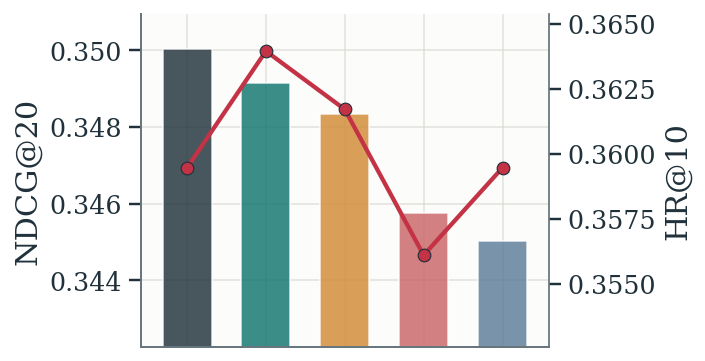

In [4]:
plot_intervention_panel('KuaiRecLargeStrictPosV2_0.2', 'a05_intervention_metrics_a.pdf')

Foursquare | intervention summary
[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_intervention_metrics_b.pdf


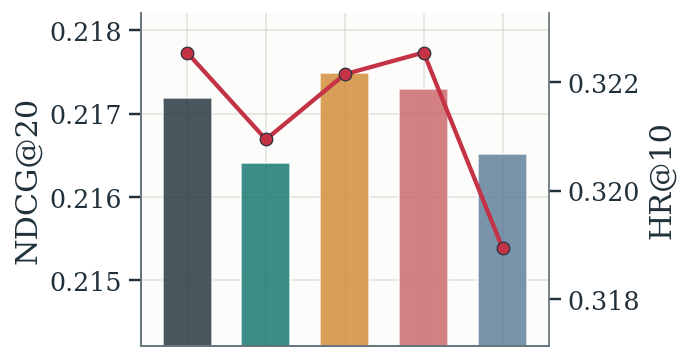

In [6]:
plot_intervention_panel('foursquare', 'a05_intervention_metrics_b.pdf')

LastFM | intervention summary
[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_intervention_metrics_c.pdf


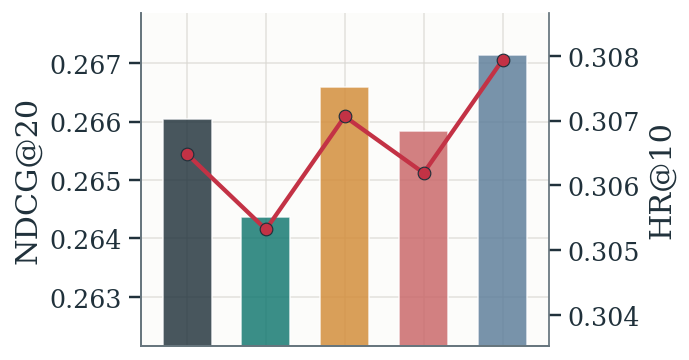

In [21]:
plot_intervention_panel('lastfm0.03', 'a05_intervention_metrics_c.pdf')

Retail Rocket | intervention summary
[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_intervention_metrics_d.pdf


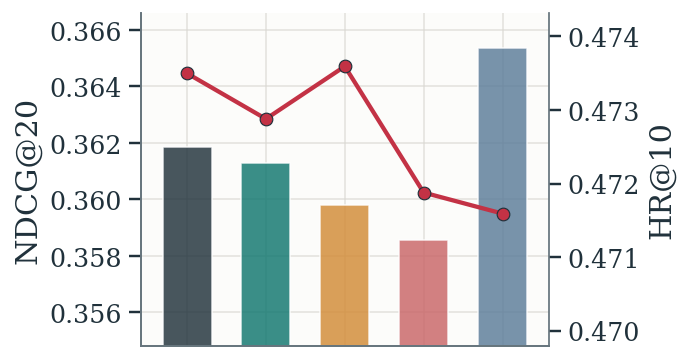

In [22]:
plot_intervention_panel('retail_rocket', 'a05_intervention_metrics_d.pdf')

[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_intervention_metrics_legend.pdf


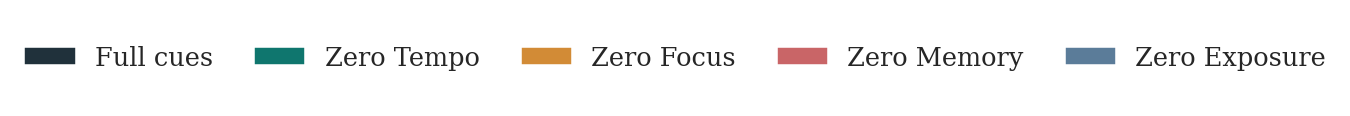

In [23]:
fig, ax = legend_strip_axes()
add_legend_strip(ax, order, [interv_palette[label] for label in order], ncol=5)
fig.savefig(FIG_DIR / 'a05_intervention_metrics_legend.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'a05_intervention_metrics_legend.pdf')
plt.show()

Original | routing profile
[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_routing_profiles_a.pdf


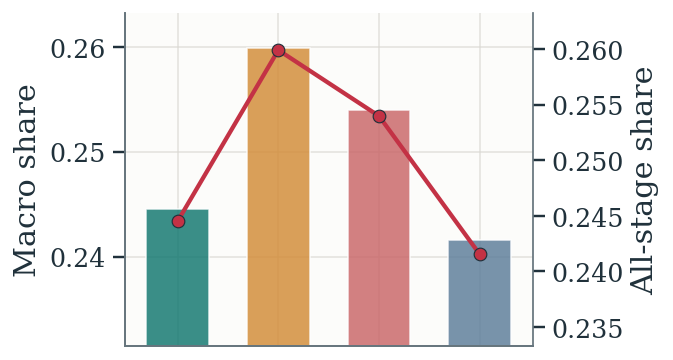

In [24]:
plot_routing_profile_panel('original', 'a05_routing_profiles_a.pdf')

Repeat-heavy | routing profile
[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_routing_profiles_b.pdf


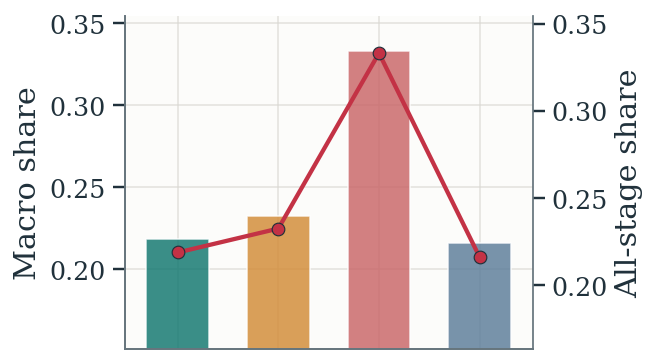

In [25]:
plot_routing_profile_panel('memory_plus', 'a05_routing_profiles_b.pdf')

Fast-tempo | routing profile
[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_routing_profiles_c.pdf


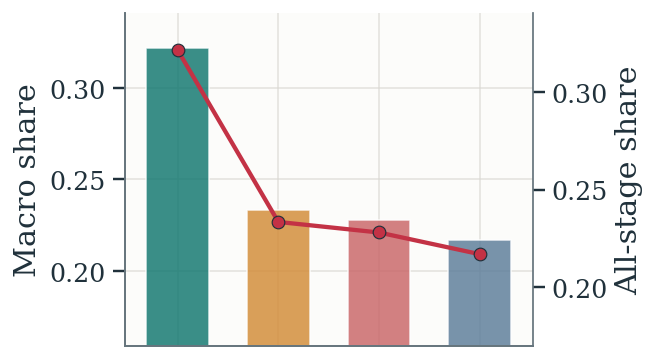

In [26]:
plot_routing_profile_panel('tempo_plus', 'a05_routing_profiles_c.pdf')

Narrow-focus | routing profile
[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_routing_profiles_d.pdf


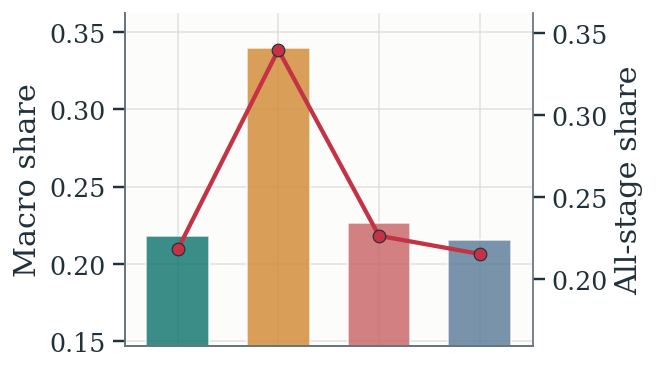

In [27]:
plot_routing_profile_panel('focus_plus', 'a05_routing_profiles_d.pdf')

[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_routing_profiles_legend.pdf


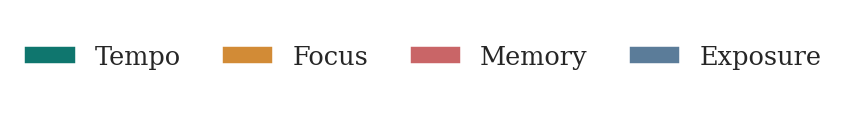

In [28]:
fig, ax = half_legend_strip_axes()
add_legend_strip(ax, ['Tempo', 'Focus', 'Memory', 'Exposure'], [family_palette['Tempo'], family_palette['Focus'], family_palette['Memory'], family_palette['Exposure']], ncol=4)
fig.savefig(FIG_DIR / 'a05_routing_profiles_legend.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'a05_routing_profiles_legend.pdf')
plt.show()